#Data Set Creation For Travel and Delay Time


In [ ]:
import numpy as np
import pandas as pd

num_entries = 2000  # Number of dataset entries

In [ ]:
# Define clusters of stops
clusters = {
    0: [1, 2, 3],    # Cluster 1: Stops 0, 1, 2, 3
    4: [5, 6, 7],    # Cluster 2: Stops 4, 5, 6, 7
    8: [9, 10]       # Cluster 3: Stops 8, 9, 10
}

# Update travel distances with cluster-based variations
for cluster, stops in clusters.items():
    for i in stops:
        for j in stops:
            if i != j:
                base_travel_distance[(i, j)] = np.random.uniform(10, 30)  # Close distances within clusters

# Add occasional outliers
for _ in range(10):  # Add 10 outliers
    stop_i = np.random.randint(0, 11)
    stop_j = np.random.randint(0, 11)
    if stop_i != stop_j:
        base_travel_distance[(stop_i, stop_j)] = np.random.uniform(50, 100)  # Longer distances
        base_travel_distance[(stop_j, stop_i)] = base_travel_distance[(stop_i, stop_j)]  # Symmetry

# Recalculate base travel times
base_travel_time = {k: v / 50 * 3600 for k, v in base_travel_distance.items()}  # Time at 50 km/h

# Generate the dataset with updated logic
travel_distance_pattern = []
travel_time_pattern = []
delay_time_pattern = []
stops_i = []
stops_j = []
delay_events = []

for _ in range(num_entries):
    stop_i = np.random.randint(0, 11)  # Random stop
    stop_j = np.random.randint(0, 11)

    # Ensure stop_i != stop_j
    while stop_i == stop_j:
        stop_j = np.random.randint(0, 11)

    # Use base travel distance and add variation
    if (stop_i, stop_j) in base_travel_distance:
        distance = base_travel_distance[(stop_i, stop_j)] + np.random.uniform(-3, 3)
        time = base_travel_time[(stop_i, stop_j)] + np.random.uniform(-300, 300)
        time = time / 3600
    else:
        distance = np.random.uniform(30, 100)  # Random distance if not defined
        time = distance / 50 + np.random.uniform(-0.1, 0.1)

    # Add delay
    if np.random.rand() < 0.7:  # 70% chance of delay
        delay = base_delay_time + np.random.uniform(300, 1200)
        delay = delay / 3600
        event = np.random.choice(delay_reasons[:-1])
    else:
        delay = base_delay_time + np.random.uniform(-10, 10)
        delay = delay / 3600
        event = "No Delay"

    # Append to lists
    stops_i.append(stop_i)
    stops_j.append(stop_j)
    travel_distance_pattern.append(distance)
    travel_time_pattern.append(time)
    delay_time_pattern.append(delay)
    delay_events.append(event)

# Create updated DataFrame
stop_pairs_pattern = pd.DataFrame({
    'stop_i': stops_i,
    'stop_j': stops_j,
    'travel_distance_km': travel_distance_pattern,
    'travel_time_seconds': travel_time_pattern,
    'delay_time_seconds': delay_time_pattern,
    'delay_event': delay_events
})

# Display the updated dataset
print(stop_pairs_pattern.head())


NameError: name 'base_travel_distance' is not defined

In [ ]:
import numpy as np
import pandas as pd

num_entries = 2000  # Number of dataset entries
K = 3  # Number of products

# Base travel distances between specific stop pairs
base_travel_distance = {

    (0, 1): 55, (0, 2): 50, (0, 3): 45, (0, 4): 40, (0, 5): 35,
    (0, 6): 60, (0, 7): 65, (0, 8): 70, (0, 9): 75, (0, 10): 80,

    # Distances between stop 1 and other stops
    (1, 2): 30, (1, 3): 40, (1, 4): 50, (1, 5): 60, (1, 6): 65,
    (1, 7): 70, (1, 8): 75, (1, 9): 80, (1, 10): 85,

    # Distances between stop 2 and other stops
    (2, 3): 35, (2, 4): 45, (2, 5): 55, (2, 6): 50,
    (2, 7): 55, (2, 8): 60, (2, 9): 65, (2, 10): 70,

    # Distances between stop 3 and other stops
    (3, 4): 25, (3, 5): 30, (3, 6): 40, (3, 7): 45, (3, 8): 50,
    (3, 9): 55, (3, 10): 60,

    # Distances between stop 4 and other stops
    (4, 5): 20, (4, 6): 35, (4, 7): 40, (4, 8): 45, (4, 9): 50,
    (4, 10): 55,

    # Distances between stop 5 and other stops
    (5, 6): 25, (5, 7): 30, (5, 8): 35, (5, 9): 40, (5, 10): 45,

    # Distances between stop 6 and other stops
    (6, 7): 20, (6, 8): 25, (6, 9): 30, (6, 10): 35,

    # Distances between stop 7 and other stops
    (7, 8): 15, (7, 9): 20, (7, 10): 25,

    # Distances between stop 8 and other stops
    (8, 9): 10, (8, 10): 15,

    # Distance between stop 9 and stop 10
    (9, 10): 10,
}

# Add symmetric distances
symmetric_travel_distance = {}
for (i, j), dist in base_travel_distance.items():
    symmetric_travel_distance[(i, j)] = dist
    symmetric_travel_distance[(j, i)] = dist  # Make symmetric

base_travel_distance = symmetric_travel_distance


# Calculate base travel times in seconds
base_travel_time = {k: v / 50*3600  for k, v in base_travel_distance.items()}  # Base time at 50 km/h
base_delay_time = 600  # Base delay time in seconds

# Delay reasons list
delay_reasons = ["Road Closed", "Traffic", "Accident", "Weather", "No Delay"]

# Lists to store generated data
travel_distance_pattern = []
travel_time_pattern = []
delay_time_pattern = []
stops_i = []
stops_j = []
delay_events = []

# Generate shelf life and quality factors
SL_0 = 700 * np.random.rand(K)  # Initial shelf life for each product
SL_r = 100 * np.random.rand(K)  # Required shelf life at destination for each product
Q = np.random.uniform(0.5, 1, K)  # Quality reduction factor for each product

for _ in range(num_entries):
    stop_i = np.random.randint(0, 10)  # Random stop 1-5
    stop_j = np.random.randint(0, 10)

    # Ensure stop_i != stop_j
    while stop_i == stop_j:
        stop_j = np.random.randint(1, 10)

    # Use base travel distance and add some variation
    if (stop_i, stop_j) in base_travel_distance:
        distance = base_travel_distance[(stop_i, stop_j)] + np.random.uniform(-5, 5)
        time = base_travel_time[(stop_i, stop_j)] + np.random.uniform(-300, 300)
        time = time/3600
    else:
        distance = base_travel_distance[(stop_j, stop_i)] + np.random.uniform(-5, 5)
        time = base_travel_time[(stop_j, stop_i)] + np.random.uniform(-300, 300)
        time = time/3600

    # Delay with small variation
    if np.random.rand() < 0.5:  # Add random variation in 10% of cases
        delay = base_delay_time + np.random.uniform(300, 600)
        delay = delay/3600
        event = np.random.choice(delay_reasons[:-1])  # Select a reason excluding "No Delay"
    else:
        delay = base_delay_time + np.random.uniform(-3, 3)
        delay = delay/3600
        event = "No Delay"  # No significant delay

    # Append to lists
    stops_i.append(stop_i)
    stops_j.append(stop_j)
    travel_distance_pattern.append(distance)
    travel_time_pattern.append(time)
    delay_time_pattern.append(delay)
    delay_events.append(event)

# Create a DataFrame with stop pairs and generated values
stop_pairs_pattern = pd.DataFrame({
    'stop_i': stops_i,
    'stop_j': stops_j,
    'travel_distance_km': travel_distance_pattern,
    'travel_time_seconds': travel_time_pattern,
    'delay_time_seconds': delay_time_pattern,
    'delay_event': delay_events
})


# Display the first few rows
print(stop_pairs_pattern.head())


   stop_i  stop_j  travel_distance_km  travel_time_seconds  \
0       4       3           24.289352             0.523922   
1       8       2           58.588835             1.262009   
2       1       7           68.554831             1.332855   
3       8       4           40.280466             0.893697   
4       6       0           58.449062             1.215545   

   delay_time_seconds delay_event  
0            0.305847    Accident  
1            0.258405    Accident  
2            0.260849     Traffic  
3            0.165848    No Delay  
4            0.278159    Accident  


In [ ]:
stop_pairs_pattern

,stop_i,stop_j,travel_distance_km,travel_time_seconds,delay_time_seconds,delay_event
0,7,2,54.526374,1.117912,0.167445,No Delay
1,2,8,62.739673,1.235338,0.304751,Weather
2,8,6,29.200658,0.571239,0.328725,Accident
3,4,5,23.817099,0.475698,0.312224,Accident
4,3,9,51.503807,1.133917,0.167227,No Delay
...,...,...,...,...,...,...
1995,2,4,47.108519,0.892425,0.166393,No Delay
1996,6,5,22.984005,0.570004,0.250719,Road Closed
1997,8,6,29.261430,0.477239,0.262874,Accident
1998,3,8,46.674823,0.922119,0.167196,No Delay


# Prediction using Neural Network

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder

# One-hot encode stop_i and stop_j
encoder = OneHotEncoder(categories='auto', drop='first')
encoded_stops = encoder.fit_transform(stop_pairs_pattern[['stop_i', 'stop_j']]).toarray()

# Update feature matrix with one-hot encoded stops
X = np.concatenate((encoded_stops, stop_pairs_pattern[['travel_distance_km', 'delay_time_seconds']].values), axis=1)

y = stop_pairs_pattern['travel_time_seconds'].values

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))  # Input layer
model.add(Dense(32, activation='relu'))  # Hidden layer
model.add(Dense(1, activation='linear'))  # Output layer for regression

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X_train, y_train, epochs=100, batch_size=8, verbose=1)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

accuracy = 100 - np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"Accuracy: {accuracy}%")

KeyboardInterrupt: 

#Data Set Creation Of Produces and Shelf Life

In [ ]:
import numpy as np
import pandas as pd

num_entries = 500  # Number of dataset entries

# Define the types of produce and their typical characteristics
produce_types = ['Apples', 'Bananas', 'Tomatoes', 'xyz']

# Define base shelf life (in hours) for each produce type
base_shelf_life = {
    'Apples': 720,   # 30 days
    'Bananas': 168,  # 7 days
    'Tomatoes': 336  # 14 days
    ,'xyz': 200
}

temperature_range = {
    'Apples': (0, 4),
    'Bananas': (12, 14),
    'Tomatoes': (7, 10)
    ,'xyz': (0, 10)
}

# Lists to store generated data
produce_type_list = []
weight_list = []
shelf_life_list = []
transport_temperature_list = []

for _ in range(num_entries):
    produce = np.random.choice(produce_types)

    weight = np.random.uniform(0.5, 20)

    # Shelf life with some variation (up to ±10%)
    shelf_life = base_shelf_life[produce] + np.random.uniform(-0.1, 0.1) * base_shelf_life[produce]

    # Transportation temperature within defined range for the selected produce
    transport_temperature = np.random.uniform(*temperature_range[produce])

    # Append to lists
    produce_type_list.append(produce)
    weight_list.append(weight)
    shelf_life_list.append(shelf_life)
    transport_temperature_list.append(transport_temperature)

# Create a DataFrame with the generated data
produce_data = pd.DataFrame({
    'produce_type': produce_type_list,
    'weight_kg': weight_list,
    'shelf_life_hours': shelf_life_list,
    'transport_temperature_C': transport_temperature_list
})

print(produce_data.head())


  produce_type  weight_kg  shelf_life_hours  transport_temperature_C
0     Tomatoes   9.820797        316.906733                 7.746201
1      Bananas  18.747276        182.744589                13.847698
2     Tomatoes   8.272712        337.604848                 9.653130
3     Tomatoes   5.109343        339.901804                 9.058339
4      Bananas  12.723203        178.148315                13.354476


In [ ]:
produce_data

,produce_type,weight_kg,shelf_life_hours,transport_temperature_C
0,Bananas,16.589740,152.893260,12.155208
1,Apples,8.824921,727.458003,0.737839
2,Tomatoes,11.212581,344.344859,9.910851
3,Tomatoes,14.836003,355.013116,9.995677
4,Tomatoes,7.505941,326.319039,8.072125
...,...,...,...,...
495,xyz,6.175551,206.393801,1.528657
496,Bananas,1.113376,165.387773,12.672788
497,Tomatoes,13.193628,330.352810,8.231235
498,Bananas,5.888119,154.649637,13.208108


#Reinforcement Model Approach

In [ ]:
import numpy as np
import random

stops = [1, 2, 3, 4, 5]  # Actual stops
produce_types = ['Apples', 'Bananas', 'Tomatoes']
num_produces = len(produce_types)

Q_table = np.zeros((len(stops), len(stops), num_produces))  # (current stop, next stop, produce type)

# Parameters
alpha = 0.1  # Learning rate
gamma = 0.95  # Discount factor
epsilon = 0.2  # Exploration-exploitation tradeoff

# Reward function: this can be more complex (distance, time, shelf life, delay, etc.)
def calculate_reward(current_stop, next_stop, produce_type, shelf_life):
    distance = base_travel_distance.get((current_stop, next_stop), base_travel_distance.get((next_stop, current_stop), 0))
    if shelf_life > 0:
        return 100 - distance  # Higher reward for shorter distance and not expired
    else:
        return -100  # Penalty for spoilage

def choose_action(state):
    current_stop_idx = state[0] - 1  # Convert stop to 0-indexed
    if np.random.rand() < epsilon:
        # Explore: randomly select the next stop and produce to deliver
        next_stop = random.choice(stops)
        produce_idx = random.choice(range(num_produces))
    else:
        # Exploit: choose action with the highest Q-value
        action_idx = np.argmax(Q_table[current_stop_idx, :, :])
        next_stop, produce_idx = np.unravel_index(action_idx, (len(stops), num_produces))
        next_stop = next_stop + 1  # Convert back to 1-indexed
    return next_stop, produce_idx

def update_Q_table(state, action, reward, next_state):
    current_stop_idx = state[0] - 1  # Convert stop to 0-indexed
    next_stop_idx = action[0] - 1    # Convert stop to 0-indexed
    current_Q = Q_table[current_stop_idx, next_stop_idx, action[1]]
    max_future_Q = np.max(Q_table[next_stop_idx, :, :])
    Q_table[current_stop_idx, next_stop_idx, action[1]] = current_Q + alpha * (reward + gamma * max_future_Q - current_Q)

for episode in range(1000):
    current_stop = random.choice(stops)
    produces = [(produce, np.random.uniform(5, 20), base_shelf_life[produce]) for produce in produce_types]  # (produce type, weight, shelf life)

    for step in range(50):  # Simulate multiple steps in an episode
        next_stop, produce_idx = choose_action((current_stop, produces))
        produce, weight, shelf_life = produces[produce_idx]

        # Calculate reward
        reward = calculate_reward(current_stop, next_stop, produce, shelf_life)

        # Update the Q-table
        next_state = (next_stop, produces)
        update_Q_table((current_stop, produces), (next_stop, produce_idx), reward, next_state)

        # Move to the next stop
        current_stop = next_stop

        # Update shelf life (as time passes during transit)
        for i in range(len(produces)):
            produces[i] = (produces[i][0], produces[i][1], produces[i][2] - 1)  # Decrease shelf life by 1 hour

        # Break if all produces are delivered
        if all([p[2] <= 0 for p in produces]):
            break


In [ ]:
total_rewards = []

# Simulate an episode
for episode in range(1000):
    current_stop = random.choice(stops)
    produces = [(produce, np.random.uniform(5, 20), base_shelf_life[produce]) for produce in produce_types]  # (produce type, weight, shelf life)
    episode_reward = 0  # Track total reward for this episode

    for step in range(50):  # Simulate multiple steps in an episode
        next_stop, produce_idx = choose_action((current_stop, produces))
        produce, weight, shelf_life = produces[produce_idx]

        reward = calculate_reward(current_stop, next_stop, produce, shelf_life)
        episode_reward += reward  # Sum up rewards

        next_state = (next_stop, produces)
        update_Q_table((current_stop, produces), (next_stop, produce_idx), reward, next_state)

        current_stop = next_stop
        for i in range(len(produces)):
            produces[i] = (produces[i][0], produces[i][1], produces[i][2] - 1)  # Decrease shelf life by 1 hour

        if all([p[2] <= 0 for p in produces]):
            break

    total_rewards.append(episode_reward)


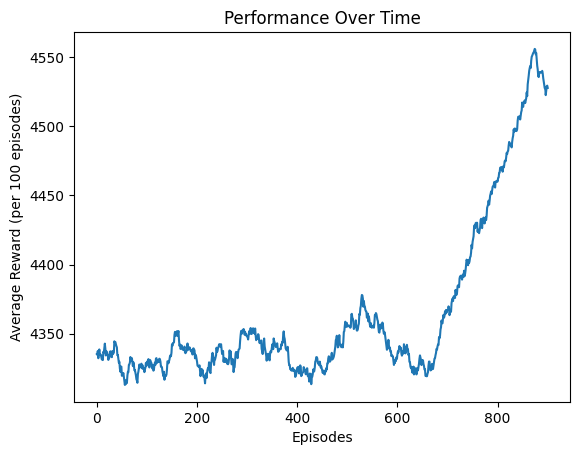

In [ ]:
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Example: Calculate a 100-episode moving average of rewards
window_size = 100
avg_rewards = moving_average(total_rewards, window_size)

# Plot the average rewards
import matplotlib.pyplot as plt
plt.plot(avg_rewards)
plt.xlabel('Episodes')
plt.ylabel('Average Reward (per 100 episodes)')
plt.title('Performance Over Time')
plt.show()


In [ ]:
def find_optimal_route(start_stop, max_steps=50):
    current_stop = start_stop
    produces = [(produce, np.random.uniform(5, 20), base_shelf_life[produce]) for produce in produce_types]  # (produce type, weight, shelf life)
    route = []

    for step in range(max_steps):
        current_stop_idx = current_stop - 1  # Convert stop to 0-indexed

        action_idx = np.argmax(Q_table[current_stop_idx, :, :])
        next_stop, produce_idx = np.unravel_index(action_idx, (len(stops), num_produces))
        next_stop = next_stop + 1  # Convert back to 1-indexed

        produce, weight, shelf_life = produces[produce_idx]

        route.append((current_stop, next_stop, produce))

        # Update shelf life and move to next stop
        current_stop = next_stop
        produces[produce_idx] = (produce, weight, shelf_life - 1)
        # Termination condition: if all produces are expired, break
        if all([p[2] <= 0 for p in produces]):
            print("All produces have expired.")
            break

    return route


In [ ]:
optimal_route = find_optimal_route(3)  # Start at stop 3
print("Optimal Route:", optimal_route[0])


Optimal Route: (3, 1, 'Apples')


In [ ]:
import numpy as np
import pandas as pd
import random
from collections import defaultdict

class DeliveryEnv:
    def __init__(self, stop_pairs_pattern, produce_data, max_steps=50):
        self.stop_pairs_pattern = stop_pairs_pattern
        self.produce_data = produce_data
        self.max_steps = max_steps
        self.reset()

    def reset(self):
        self.warehouse_location = 0
        self.current_location = self.warehouse_location
        self.current_inventory = {'Apples': 25, 'Bananas': 25, 'Tomatoes': 25}
        self.elapsed_time = 0
        self.shelf_life_remaining = self.calculate_initial_shelf_life()
        self.route_log = []
        self.steps = 0
        self.visited_stops = set([self.warehouse_location])
        self.log_initial_stop()
        return self.get_state()

    def calculate_initial_shelf_life(self):
        base_shelf_life = {'Apples': 720, 'Bananas': 168, 'Tomatoes': 336}
        return {produce: base_shelf_life[produce] for produce in self.current_inventory.keys()}

    def q10_model(self, shelf_life, temperature):
        q10 = 2
        t_base = 20
        return shelf_life * (q10 ** ((temperature - t_base) / 10))

    def get_state(self):
        state = [
            self.current_location,
            self.current_inventory['Apples'],
            self.current_inventory['Bananas'],
            self.current_inventory['Tomatoes'],
            self.shelf_life_remaining['Apples'],
            self.shelf_life_remaining['Bananas'],
            self.shelf_life_remaining['Tomatoes'],
            self.elapsed_time
        ]
        return state

    def get_next_states(self):
        next_states = []
        for _, row in self.stop_pairs_pattern.iterrows():
            if ((row['stop_i'] == self.current_location and row['stop_j'] not in self.visited_stops) or
                (row['stop_j'] == self.current_location and row['stop_i'] not in self.visited_stops)):
                next_stop = row['stop_j'] if row['stop_i'] == self.current_location else row['stop_i']
                travel_distance = row['travel_distance_km']
                delay_time = row['delay_time_seconds']
                required_produce = self.produce_data[next_stop]
                next_states.append((next_stop, travel_distance, delay_time, required_produce))
        return next_states

    def update_inventory(self, produce, amount):
        if self.current_inventory[produce] >= amount:
            self.current_inventory[produce] -= amount
            return True
        return False

    def calculate_reward(self, travel_time, delivered_produce_count):
        time_penalty = travel_time
        produce_reward = delivered_produce_count
        return produce_reward - time_penalty

    def log_initial_stop(self):
        self.route_log.append({
            'Stop': self.warehouse_location,
            'Travel Distance': 0,
            'Delay': 0,
            'Elapsed Time': self.elapsed_time,
            'Shelf Life Remaining': self.shelf_life_remaining.copy(),
            'Delivered Produce': {},
            'Reward': 0
        })

    def log_route(self, action, delivered_produce, reward):
        self.route_log.append({
            'Stop': action[0],
            'Travel Distance': action[1],
            'Delay': action[2],
            'Elapsed Time': self.elapsed_time,
            'Shelf Life Remaining': self.shelf_life_remaining.copy(),
            'Delivered Produce': delivered_produce.copy(),
            'Reward': reward
        })

    def step(self, action):
        next_stop, travel_distance, delay, delivered_produce = action[0], action[1], action[2], action[3]

        # Check for route existence
        travel_time_series = self.stop_pairs_pattern.loc[
            (self.stop_pairs_pattern['stop_i'] == self.current_location) &
            (self.stop_pairs_pattern['stop_j'] == next_stop), 'travel_time_seconds'
        ]
        if travel_time_series.empty:
            print(f"No route found from {self.current_location} to {next_stop}.")
            return self.get_state(), -1, True

        travel_time = travel_time_series.values[0]
        self.elapsed_time += travel_time + delay
        self.steps += 1
        self.visited_stops.add(next_stop)

        # Update shelf life using Q10 model for each produce type
        for produce in self.current_inventory.keys():
            self.shelf_life_remaining[produce] = self.q10_model(self.shelf_life_remaining[produce], 4)

        # Deliver produce and update inventory
        delivered_produce_count = 0
        for produce, amount in delivered_produce.items():
            if self.update_inventory(produce, amount):
                delivered_produce_count += amount

        # Calculate reward
        reward = self.calculate_reward(travel_time, delivered_produce_count)
        self.log_route(action, delivered_produce, reward)

        # Update current location
        self.current_location = next_stop

        # Check for completion
        done = (self.steps >= self.max_steps or
                (len(self.visited_stops) == len(self.stop_pairs_pattern) + 1 and next_stop == self.warehouse_location) or
                all(value == 0 for value in self.current_inventory.values()))

        # Automatically return to the warehouse if all produce is delivered
        if done and self.current_location != self.warehouse_location:
            self.current_location = self.warehouse_location
            self.log_initial_stop()

        return self.get_state(), reward, done

    def print_route_log(self):
        for step in self.route_log:
            print(f"Stop: {step['Stop']}, Travel Distance: {step['Travel Distance']} km, "
                  f"Delay: {step['Delay']} sec, Elapsed Time: {step['Elapsed Time']} sec, Reward: {step['Reward']}")
            print(" Shelf Life Remaining:", step['Shelf Life Remaining'])
            print(" Delivered Produce:", step['Delivered Produce'])
            print("")



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

# Define the Q-Network
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size, hidden_size=64):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Define the RL Agent
class DQNAgent:
    def __init__(self, state_size, action_size, learning_rate=0.001, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        self.memory = deque(maxlen=2000)
        self.model = QNetwork(state_size, action_size)
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)

    # Update the encode_action function to handle empty next_states gracefully
    def encode_action(action_idx, next_states):
        if not next_states or action_idx >= len(next_states):
            return None  # Return None to signify invalid action
        return next_states[action_idx]

    # Update the DeliveryEnv's step function to handle invalid actions
    def step(self, action):
        if action is None:  # Invalid action
            return self.get_state(), -10, True  # Penalize invalid actions

        next_stop, travel_distance, delay, delivered_produce = action
        ...
        # Rest of the step logic remains unchanged
        return self.get_state(), reward, done

    # Updated DQNAgent's act method
    def act(self, state, valid_actions_count):
        if random.random() < self.epsilon or valid_actions_count == 0:
            return random.randint(0, valid_actions_count - 1) if valid_actions_count > 0 else 0
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.model(state_tensor)
        return torch.argmax(q_values[:valid_actions_count]).item()


    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self, batch_size=32):
        if len(self.memory) < batch_size:
            return
        batch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in batch:
            state_tensor = torch.FloatTensor(state)
            next_state_tensor = torch.FloatTensor(next_state)
            target = reward
            if not done:
                target += self.gamma * torch.max(self.model(next_state_tensor)).item()
            target_f = self.model(state_tensor)
            target_f[action] = target
            self.optimizer.zero_grad()
            loss = nn.functional.mse_loss(self.model(state_tensor), target_f)
            loss.backward()
            self.optimizer.step()
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# Convert state and actions to indices (discretization)
def encode_action(action_idx, next_states):
    if action_idx >= len(next_states):
        return (0, 0, 0, {})  # Default action to avoid errors
    return next_states[action_idx]



In [ ]:
env = DeliveryEnv(stop_pairs_pattern, produce_data, max_steps=10)
state_size = len(env.get_state())
action_size = len(stop_pairs_pattern)
agent = DQNAgent(state_size, action_size)

episodes = 10
batch_size = 32

# Training loop with adjustments
for e in range(episodes):
    state = env.reset()
    done = False
    total_reward = 0
    while not done:
        next_states = env.get_next_states()
        action_idx = agent.act(state, len(next_states))  # Consider valid actions only
        action = encode_action(action_idx, next_states)
        next_state, reward, done = env.step(action)
        agent.remember(state, action_idx, reward, next_state, done)
        state = next_state
        total_reward += reward
        if done:
            print(f"Episode {e + 1}: Total Reward: {total_reward}")
            break
    agent.replay(batch_size)

print("\nRoute Log:")
env.print_route_log()

KeyError: 5

In [ ]:
import numpy as np
import pandas as pd
import random

class DeliveryEnv:
    def __init__(self, stops_data, produce_data, max_steps=50):
        self.stops_data = stops_data
        self.produce_data = produce_data
        self.max_steps = max_steps
        self.reset()

    def reset(self):
        self.warehouse_location = 1
        self.current_location = self.warehouse_location
        self.current_inventory = {'Apples': 25, 'Bananas': 25, 'Tomatoes': 25}
        self.elapsed_time = 0
        self.shelf_life_remaining = self.calculate_initial_shelf_life()
        self.route_log = []
        self.steps = 0
        self.visited_stops = set([self.warehouse_location])
        self.log_initial_stop()

    def calculate_initial_shelf_life(self):
        base_shelf_life = {'Apples': 720, 'Bananas': 168, 'Tomatoes': 336}
        return {produce: base_shelf_life[produce] for produce in self.current_inventory.keys()}

    def q10_model(self, shelf_life, temperature):
        q10 = 2
        t_base = 20
        return shelf_life * (q10 ** ((temperature - t_base) / 10))

    def get_state(self):
        state = [
            self.current_location,
            self.current_inventory['Apples'],
            self.current_inventory['Bananas'],
            self.current_inventory['Tomatoes'],
            self.shelf_life_remaining['Apples'],
            self.shelf_life_remaining['Bananas'],
            self.shelf_life_remaining['Tomatoes'],
            self.elapsed_time
        ]
        return state

    def get_next_states(self):
        next_states = []
        for _, row in self.stops_data.iterrows():
            if ((row['stop_i'] == self.current_location and row['stop_j'] not in self.visited_stops) or
                (row['stop_j'] == self.current_location and row['stop_i'] not in self.visited_stops)):
                next_stop = row['stop_j'] if row['stop_i'] == self.current_location else row['stop_i']
                travel_distance = row['travel_distance_km']
                delay_time = row['delay_time_seconds']
                next_states.append((next_stop, travel_distance, delay_time))
        return next_states

    def update_inventory(self, produce, amount):
        if self.current_inventory[produce] >= amount:
            self.current_inventory[produce] -= amount
            return True
        return False

    def calculate_reward(self, travel_time, delivered_produce_count):
        time_reward = travel_time
        produce_reward = delivered_produce_count
        return time_reward - produce_reward

    def log_initial_stop(self):
        self.route_log.append({
            'Stop': self.warehouse_location,
            'Travel Distance': 0,
            'Delay': 0,
            'Elapsed Time': self.elapsed_time,
            'Shelf Life Remaining': self.shelf_life_remaining.copy(),
            'Delivered Produce': {},
            'Reward': 0
        })

    def log_route(self, action, delivered_produce, reward):
        self.route_log.append({
            'Stop': action[0],
            'Travel Distance': action[1],
            'Delay': action[2],
            'Elapsed Time': self.elapsed_time,
            'Shelf Life Remaining': self.shelf_life_remaining.copy(),
            'Delivered Produce': delivered_produce.copy(),
            'Reward': reward
        })

    def step(self, action):
      next_stop, travel_distance, delay = action[0], action[1], action[2]
      delivered_produce = action[3]

      # Check for route existence
      travel_time_series = self.stops_data.loc[
          (self.stops_data['stop_i'] == self.current_location) &
          (self.stops_data['stop_j'] == next_stop), 'travel_time_seconds'
      ]
      if travel_time_series.empty:
          print(f"No route found from {self.current_location} to {next_stop}.")
          return self.get_state(), -1, True

      travel_time = travel_time_series.values[0]
      self.elapsed_time += travel_time + delay
      self.steps += 1
      self.visited_stops.add(next_stop)

      # Update shelf life using Q10 model for each produce type
      for produce in self.current_inventory.keys():
          self.shelf_life_remaining[produce] = self.q10_model(self.shelf_life_remaining[produce], 4)

      # Deliver produce and update inventory
      delivered_produce_count = 0
      for produce, amount in delivered_produce.items():
          if self.update_inventory(produce, amount):
              delivered_produce_count += amount

      # Calculate reward
      reward = self.calculate_reward(travel_time, delivered_produce_count)
      self.log_route(action, delivered_produce, reward)

      # Update current location
      self.current_location = next_stop

      # Check for completion
      done = (self.steps >= self.max_steps or
              (len(self.visited_stops) == len(self.stops_data) and next_stop == self.warehouse_location) or
              all(value == 0 for value in self.current_inventory.values()))

      # Automatically return to the warehouse if all produce is delivered
      if done and self.current_location != self.warehouse_location:
          self.current_location = self.warehouse_location
          self.log_initial_stop()

      return self.get_state(), reward, done


    def print_route_log(self):
        for step in self.route_log:
            print(f"Stop: {step['Stop']}, Travel Distance: {step['Travel Distance']} km, "
                  f"Delay: {step['Delay']} sec, Elapsed Time: {step['Elapsed Time']} sec, Reward: {step['Reward']}")
            print(" Shelf Life Remaining:", step['Shelf Life Remaining'])
            print(" Delivered Produce:", step['Delivered Produce'])
            print("")

# Example run
env = DeliveryEnv(stop_pairs_pattern, produce_data)
env.reset()
done = False
while not done:
    state = env.get_state()
    next_states = env.get_next_states()
    if not next_states:
        action = (env.warehouse_location, 0, 0, {'Apples': 0, 'Bananas': 0, 'Tomatoes': 0})
    else:
        next_stop = random.choice(next_states)
        produce_to_deliver = {'Apples': 5, 'Bananas': 5, 'Tomatoes': 5}
        action = (*next_stop, produce_to_deliver)

    state, reward, done = env.step(action)
    print(f"State: {state}, Reward: {reward}")

print("\nRoute Log:")
env.print_route_log()


State: [3, 20, 20, 20, 237.51142393912096, 55.41933225246156, 110.83866450492312, 0.9462928722972384], Reward: -14.220265884987667
State: [5, 15, 15, 15, 78.34955069665116, 18.281561829218607, 36.56312365843721, 1.8264604276272114], Reward: -14.436098334061091
State: [4, 10, 10, 10, 25.845712987433284, 6.030666363734434, 12.061332727468868, 2.46046515413263], Reward: -14.532397529432368
State: [2, 5, 5, 5, 8.525905686620987, 1.9893779935448974, 3.978755987089795, 3.7165459774010756], Reward: -14.049747712405612
State: [1, 0, 0, 0, 2.812499999999999, 0.65625, 1.3125, 5.008154716739996], Reward: -13.985403252162456

Route Log:
Stop: 1, Travel Distance: 0 km, Delay: 0 sec, Elapsed Time: 0 sec, Reward: 0
 Shelf Life Remaining: {'Apples': 720, 'Bananas': 168, 'Tomatoes': 336}
 Delivered Produce: {}

Stop: 3, Travel Distance: 44.79673299913232 km, Delay: 0.16655875728490535 sec, Elapsed Time: 0.9462928722972384 sec, Reward: -14.220265884987667
 Shelf Life Remaining: {'Apples': 237.5114239391

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

# =========================== ENVIRONMENT CLASS =========================== #


class DeliveryEnv:
    def __init__(self, stops_data, produce_data, max_steps=50):
        self.stops_data = stops_data
        self.produce_data = produce_data
        self.max_steps = max_steps
        self.all_stops = sorted(set(stops_data['stop_i'].unique()) | set(stops_data['stop_j'].unique()))
        self.n_stops = len(self.all_stops)
        self.action_space_size = self.n_stops
        self.delivery_plan = self.create_delivery_plan()  # New delivery plan
        self.reset()

    def reset(self):
        self.warehouse_location = 0
        self.current_location = self.warehouse_location
        self.current_inventory = {'Apples': 72, 'Bananas': 61, 'Tomatoes': 58, 'xyz': 53}
        self.elapsed_time = 0
        self.shelf_life_remaining = self.initialize_shelf_life()
        self.steps = 0
        self.visited_stops = {self.warehouse_location}
        self.route_log = []
        self.log_initial_stop()
        return self.get_state()
    def initialize_shelf_life(self):
        base_shelf_life = {'Apples': 720, 'Bananas': 168, 'Tomatoes': 336, 'xyz': 200}
        return base_shelf_life.copy()


    def create_delivery_plan(self):
        """Create a predefined delivery plan for each stop."""
        plan = {
            1: {'Apples': 10, 'Bananas': 5, 'Tomatoes': 5, 'xyz': 0},
            2: {'Apples': 5, 'Bananas': 10, 'Tomatoes': 5, 'xyz': 5},
            3: {'Apples': 5, 'Bananas': 5, 'Tomatoes': 10, 'xyz': 5},
            4: {'Apples': 10, 'Bananas': 5, 'Tomatoes': 0, 'xyz': 10},
            5: {'Apples': 7, 'Bananas': 7, 'Tomatoes': 6, 'xyz': 5},
            6: {'Apples': 8, 'Bananas': 5, 'Tomatoes': 7, 'xyz': 5},
            7: {'Apples': 6, 'Bananas': 8, 'Tomatoes': 6, 'xyz': 5},
            8: {'Apples': 5, 'Bananas': 5, 'Tomatoes': 8, 'xyz': 7},
            9: {'Apples': 10, 'Bananas': 5, 'Tomatoes': 5, 'xyz': 5},
            10: {'Apples': 6, 'Bananas': 6, 'Tomatoes': 6, 'xyz': 6},
        }
        return plan

    def get_state(self):
        return [
            self.current_location,
            self.current_inventory['Apples'],
            self.current_inventory['Bananas'],
            self.current_inventory['Tomatoes'],
            self.current_inventory['xyz'],
            self.shelf_life_remaining['Apples'],
            self.shelf_life_remaining['Bananas'],
            self.shelf_life_remaining['Tomatoes'],
            self.shelf_life_remaining['xyz'],
            self.elapsed_time,
        ]

    def get_nearest_stops(self):
        """Fetch all unvisited stops sorted by distance."""
        unvisited_routes = self.stops_data[
            ((self.stops_data['stop_i'] == self.current_location) & (~self.stops_data['stop_j'].isin(self.visited_stops))) |
            ((self.stops_data['stop_j'] == self.current_location) & (~self.stops_data['stop_i'].isin(self.visited_stops)))
        ]
        if unvisited_routes.empty:
            return []

        unvisited_routes = unvisited_routes.copy()
        unvisited_routes['next_stop'] = np.where(
            unvisited_routes['stop_i'] == self.current_location,
            unvisited_routes['stop_j'],
            unvisited_routes['stop_i']
        )
        return unvisited_routes[['next_stop', 'travel_distance_km', 'travel_time_seconds']].values.tolist()

    def select_stop(self, nearest_stops):
        """Select the next stop based on weighted scoring with priority to distance."""
        best_stop = None
        best_score = float('inf')  # Smaller scores are better for prioritizing distance

        for stop in nearest_stops:
            next_stop, travel_distance_km, _ = stop
            delivery = self.delivery_plan.get(next_stop, {})
            delivery_score = sum(min(self.current_inventory[p], v) for p, v in delivery.items())
            avg_shelf_life = np.mean([self.shelf_life_remaining[p] for p in delivery if delivery[p] > 0])

            # Weighted scoring: prioritize distance, then delivery quantity, then shelf life
            score = (10 * travel_distance_km) - (2 * delivery_score) - avg_shelf_life

            if score < best_score:  # Lower score is better
                best_score = score
                best_stop = stop

        return best_stop


    def step(self, action):
        nearest_stops = self.get_nearest_stops()
        if not nearest_stops:
            return self.handle_no_stops()

        # Select the best stop based on delivery plan and shelf life
        best_stop = self.select_stop(nearest_stops)
        if not best_stop:
            return self.handle_no_stops()

        next_stop, _, travel_time = best_stop

        # Update environment
        self.elapsed_time += travel_time
        self.steps += 1
        self.update_shelf_life()

        delivery = self.delivery_plan.get(next_stop, {})
        delivered_count = sum(self.update_inventory(p, amt) for p, amt in delivery.items())

        reward = self.calculate_reward(travel_time, delivered_count)

        self.current_location = next_stop
        self.visited_stops.add(next_stop)
        self.log_route(next_stop, delivery, reward)

        done = self.check_done()
        return self.get_state(), reward, done

    def update_inventory(self, produce, amount):
        """Update inventory after delivery."""
        delivered = min(self.current_inventory.get(produce, 0), amount)
        self.current_inventory[produce] -= delivered
        return delivered

    def update_shelf_life(self):
      """Update shelf life based on time elapsed and decay rate."""
      decay_rate = 0.05  # Base decay factor
      for produce in self.shelf_life_remaining:
          self.shelf_life_remaining[produce] -= self.elapsed_time * decay_rate
          self.shelf_life_remaining[produce] = max(0, self.shelf_life_remaining[produce])

# Adjust reward calculation
    def calculate_reward(self, travel_time, delivered_produce_count):
        """Calculate reward with separate penalties for travel and delivery rewards."""
        delivery_reward = delivered_produce_count * 10  # Reward for each item delivered
        travel_penalty = travel_time * 0.1  # Penalty proportional to travel time
        return delivery_reward - travel_penalty

    # Optimize the termination logic
    def check_done(self):
        """Determine if the episode should terminate."""
        return (
            self.steps >= self.max_steps
            or self.current_location == self.warehouse_location
            and len(self.visited_stops) == self.n_stops
            or all(v == 0 for v in self.current_inventory.values())
            or all(v <= 0 for v in self.shelf_life_remaining.values())
        )

    def handle_no_stops(self):
        if self.current_location != self.warehouse_location:
            self.current_location = self.warehouse_location
        return self.get_state(), -10, True  # Penalty for no valid stops

    def log_route(self, stop, delivery, reward):
        self.route_log.append({'Stop': stop, 'Delivered': delivery, 'Reward': reward})

    def log_initial_stop(self):
        self.route_log.append({'Stop': self.warehouse_location, 'Reward': 0})



# =========================== DQN AGENT =========================== #
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01
        self.learning_rate = 0.0005
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = self.build_model().to(self.device)
        self.target_model = self.build_model().to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.update_target_model()

    def build_model(self):
        return nn.Sequential(
            nn.Linear(self.state_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, self.action_size)
        )

    def act(self, state):
        if random.random() <= self.epsilon:
            return random.randrange(self.action_size)
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        return torch.argmax(self.model(state)).item()

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return
        minibatch = random.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = zip(*minibatch)

        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)

        q_values = self.model(states).gather(1, actions.unsqueeze(1)).squeeze()
        max_next_q_values = self.target_model(next_states).max(1)[0].detach()
        target_q_values = rewards + (1 - dones) * self.gamma * max_next_q_values

        loss = nn.MSELoss()(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def update_target_model(self):
        self.target_model.load_state_dict(self.model.state_dict())


# =========================== TRAINING LOOP =========================== #
def train_dqn(env, episodes=500, batch_size=64):
    agent = DQNAgent(len(env.get_state()), env.action_space_size)
    for episode in range(episodes):
        state = env.reset()
        total_reward, done = 0, False

        while not done:
            action = agent.act(state)
            next_state, reward, done = env.step(action)
            agent.memory.append((state, action, reward, next_state, done))
            state = next_state
            total_reward += reward

            if len(agent.memory) > batch_size:
                agent.replay(batch_size)

        print(f"Episode {episode}, Total Reward: {total_reward:.2f}, Epsilon: {agent.epsilon:.4f}")

    return agent


In [ ]:
import matplotlib.pyplot as plt

def test_dqn_training(stop_data, produce_data, episodes=300):
    # Initialize environment
    env = DeliveryEnv(stops_data=stop_data, produce_data=produce_data, max_steps=50)

    # Train DQN agent
    rewards = []  # Track rewards for visualization
    elapsed_times = []  # Track elapsed times
    agent = DQNAgent(len(env.get_state()), env.action_space_size)

    print("Starting DQN training...\n")
    for episode in range(episodes):
        state = env.reset()
        total_reward, done = 0, False
        elapsed_time = 0

        while not done:
            action = agent.act(state)
            next_state, reward, done = env.step(action)
            agent.memory.append((state, action, reward, next_state, done))
            state = next_state
            total_reward += reward
            elapsed_time = env.elapsed_time  # Track final elapsed time

            if len(agent.memory) > 64:  # Start replay when enough experience
                agent.replay(64)

        rewards.append(total_reward)
        elapsed_times.append(elapsed_time)

        if (episode + 1) % 10 == 0:
            print(f"Episode {episode + 1}: Total Reward = {total_reward:.2f}, Elapsed Time = {elapsed_time:.2f} hours, Epsilon = {agent.epsilon:.4f}")

    # Update target model after training
    agent.update_target_model()

    # ================= VISUALIZE RESULTS ================= #
    # plt.figure(figsize=(12, 6))

    # # Plot rewards
    # plt.subplot(1, 2, 1)
    # plt.plot(range(episodes), rewards, label="Total Reward")
    # plt.xlabel("Episodes")
    # plt.ylabel("Total Reward")
    # plt.title("Reward Improvements Over Episodes")
    # plt.legend()

    # # Plot elapsed time
    # plt.subplot(1, 2, 2)
    # plt.plot(range(episodes), elapsed_times, label="Elapsed Time")
    # plt.xlabel("Episodes")
    # plt.ylabel("Elapsed Time (seconds)")
    # plt.title("Elapsed Time Minimization Over Episodes")
    # plt.legend()

    # plt.tight_layout()
    # plt.show()

    # ================= PRINT BEST ROUTE ================= #
    print("\n--- Best Route Found ---")
    env.reset()
    done = False
    while not done:
        action = agent.act(env.get_state())
        _, _, done = env.step(action)

    # Display route log
    for log in env.route_log:
        print(log)

# ================= RUN THE TEST ================= #
test_dqn_training(stop_pairs_pattern, produce_data, episodes=300)

Starting DQN training...

Episode 10: Total Reward = 2439.36, Elapsed Time = 6.36 hours, Epsilon = 0.8349
Episode 20: Total Reward = 2439.36, Elapsed Time = 6.36 hours, Epsilon = 0.5058
Episode 30: Total Reward = 2439.36, Elapsed Time = 6.36 hours, Epsilon = 0.3064
Episode 40: Total Reward = 2439.36, Elapsed Time = 6.36 hours, Epsilon = 0.1856
Episode 50: Total Reward = 2439.36, Elapsed Time = 6.36 hours, Epsilon = 0.1124
Episode 60: Total Reward = 2439.36, Elapsed Time = 6.36 hours, Epsilon = 0.0681
Episode 70: Total Reward = 2439.36, Elapsed Time = 6.36 hours, Epsilon = 0.0413
Episode 80: Total Reward = 2439.36, Elapsed Time = 6.36 hours, Epsilon = 0.0250
Episode 90: Total Reward = 2439.36, Elapsed Time = 6.36 hours, Epsilon = 0.0151
Episode 100: Total Reward = 2439.36, Elapsed Time = 6.36 hours, Epsilon = 0.0100
Episode 110: Total Reward = 2439.36, Elapsed Time = 6.36 hours, Epsilon = 0.0100
Episode 120: Total Reward = 2439.36, Elapsed Time = 6.36 hours, Epsilon = 0.0100
Episode 130

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linprog

# Optimization function
def optimization_model(stops_data, produce_data):
    """
    Perform optimization to compute the best initial route and delivery plan using linear programming.
    """
    # Define cost matrix for travel distances between stops
    cost_matrix = stops_data.pivot(index='stop_i', columns='stop_j', values='travel_distance_km').fillna(np.inf).values

    # Define delivery requirements for each stop (excluding the warehouse)
    delivery_requirements = [
        sum(plan.values()) for stop, plan in produce_data.items() if stop != 0
    ]

    # Optimization variables
    num_stops = len(delivery_requirements) + 1  # Including warehouse
    c = cost_matrix.flatten()  # Cost vector (flattened cost matrix)

    # Constraints: Ensure every stop is visited once
    A_eq = []
    b_eq = []

    # Row constraints (each stop is visited once)
    for i in range(num_stops):
        row = np.zeros(num_stops * num_stops)
        row[i * num_stops:(i + 1) * num_stops] = 1
        A_eq.append(row)
        b_eq.append(1)

    # Column constraints (each stop is left once)
    for j in range(num_stops):
        col = np.zeros(num_stops * num_stops)
        col[j::num_stops] = 1
        A_eq.append(col)
        b_eq.append(1)

    # Solve linear programming problem
    result = linprog(c, A_eq=A_eq, b_eq=b_eq, method='highs')

    # Extract optimized route
    route_matrix = result.x.reshape((num_stops, num_stops))
    optimized_route = np.argmax(route_matrix, axis=1).tolist()

    # Extract optimized delivery amounts based on predefined plan
    optimized_delivery_amounts = [
        produce_data.get(stop, {}).copy() for stop in optimized_route
    ]

    return optimized_route, optimized_delivery_amounts

# Hybrid DQN training function
def hybrid_dqn_training(stops_data, produce_data, episodes=300):
    # Initialize environment
    env = DeliveryEnv(stops_data=stops_data, produce_data=produce_data, max_steps=50)

    # Run optimization model for initial benchmark
    optimized_route, optimized_delivery_amounts = optimization_model(stops_data, produce_data)

    # Train DQN agent
    rewards = []  # Track rewards for visualization
    elapsed_times = []  # Track elapsed times
    agent = DQNAgent(len(env.get_state()), env.action_space_size)

    print("Starting Hybrid DQN training...\n")
    for episode in range(episodes):
        state = env.reset()
        total_reward, done = 0, False
        elapsed_time = 0

        while not done:
            action = agent.act(state)
            next_state, reward, done = env.step(action)

            # Compare RL decision with optimization benchmark for reward shaping
            current_route, current_delivery = env.get_current_route_and_delivery()

            # Reward shaping: higher reward if close to optimized solution
            similarity_score = compute_similarity(current_route, optimized_route, current_delivery, optimized_delivery_amounts)
            reward += similarity_score

            agent.memory.append((state, action, reward, next_state, done))
            state = next_state
            total_reward += reward
            elapsed_time = env.elapsed_time  # Track final elapsed time

            if len(agent.memory) > 64:  # Start replay when enough experience
                agent.replay(64)

        rewards.append(total_reward)
        elapsed_times.append(elapsed_time)

        if (episode + 1) % 10 == 0:
            print(f"Episode {episode + 1}: Total Reward = {total_reward:.2f}, Elapsed Time = {elapsed_time:.2f} hours, Epsilon = {agent.epsilon:.4f}")

    # Update target model after training
    agent.update_target_model()

    # ================= VISUALIZE RESULTS ================= #
    plt.figure(figsize=(12, 6))

    # Plot rewards
    plt.subplot(1, 2, 1)
    plt.plot(range(episodes), rewards, label="Total Reward")
    plt.xlabel("Episodes")
    plt.ylabel("Total Reward")
    plt.title("Reward Improvements Over Episodes")
    plt.legend()

    # Plot elapsed time
    plt.subplot(1, 2, 2)
    plt.plot(range(episodes), elapsed_times, label="Elapsed Time")
    plt.xlabel("Episodes")
    plt.ylabel("Elapsed Time (seconds)")
    plt.title("Elapsed Time Minimization Over Episodes")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # ================= PRINT BEST ROUTE ================= #
    print("\n--- Best Route Found ---")
    env.reset()
    done = False
    while not done:
        action = agent.act(env.get_state())
        _, _, done = env.step(action)

    # Display route log
    for log in env.route_log:
        print(log)

# Similarity scoring function (placeholder, replace with actual logic)
def compute_similarity(current_route, optimized_route, current_delivery, optimized_delivery):
    route_similarity = len(set(current_route) & set(optimized_route)) / len(optimized_route)  # Fraction of stops matched
    delivery_similarity = sum(
        1 - abs(c - o) / max(o, 1) for c, o in zip(current_delivery, optimized_delivery)
    ) / len(optimized_delivery)  # Fraction of delivery amounts close to optimized
    return route_similarity * 0.5 + delivery_similarity * 0.5  # Weighted similarity score

# ================= RUN THE HYBRID MODEL ================= #
hybrid_dqn_training(stop_data, produce_data, episodes=300)
